INFO: checking out_of_order...
INFO:     out_of_order check complete (0.000102 sec).
INFO: checking system...
INFO:     system check complete (0.000010 sec).
INFO: checking solvers...
INFO:     solvers check complete (0.000032 sec).
INFO: checking dup_inputs...
INFO:     dup_inputs check complete (0.000015 sec).
INFO: checking missing_recorders...
INFO:     missing_recorders check complete (0.000003 sec).
INFO: checking unserializable_options...
INFO:     unserializable_options check complete (0.000078 sec).
INFO: checking comp_has_no_outputs...
INFO:     comp_has_no_outputs check complete (0.000015 sec).
INFO: checking auto_ivc_warnings...
INFO:     auto_ivc_warnings check complete (0.000006 sec).
INFO: checking out_of_order...
INFO:     out_of_order check complete (0.000052 sec).
INFO: checking system...
INFO:     system check complete (0.000003 sec).
INFO: checking solvers...
INFO:     solvers check complete (0.000038 sec).
INFO: checking dup_inputs...
INFO:     dup_inputs check com

/opt/anaconda3/envs/wind/lib/python3.11/site-packages/py_wake/deficit_models/gaussian.py:277: UserWarning: The IEA37SimpleBastankhahGaussian model is not representative of the setup used in the literature. For this, use py_wake.literature.iea37_case_study1.IEA37CaseStudy1 instead
  DeprecatedModel.__init__(self, 'py_wake.literature.iea37_case_study1.IEA37CaseStudy1')


Optimization terminated successfully    (Exit mode 0)
            Current function value: -1385150.646433959
            Iterations: 64
            Function evaluations: 174
            Gradient evaluations: 64
Optimization Complete
-----------------------------------


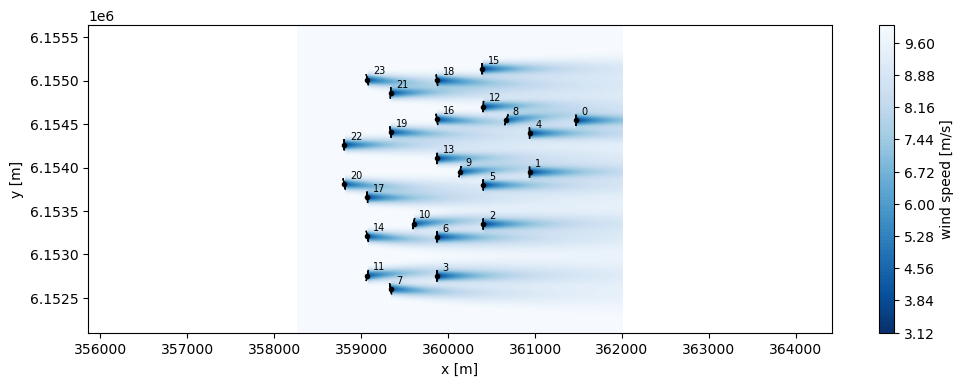

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from py_wake.examples.data.lillgrund import LillgrundSite
from py_wake.deflection_models.jimenez import JimenezWakeDeflection
from py_wake.examples.data.iea37 import IEA37_WindTurbines
from py_wake.deficit_models.gaussian import IEA37SimpleBastankhahGaussian
from topfarm.cost_models.cost_model_wrappers import CostModelComponent
from topfarm import TopFarmProblem
from topfarm.plotting import NoPlot
from topfarm.easy_drivers import EasyScipyOptimizeDriver

# Initialize site and turbine models
site = LillgrundSite()
windTurbines = IEA37_WindTurbines()
wf_model = IEA37SimpleBastankhahGaussian(site, windTurbines, deflectionModel=JimenezWakeDeflection())

# Define wind conditions
wsp = np.asarray([10])  # Wind speed
wdir = np.asarray([270])  # Wind direction

# Get initial turbine positions
x, y = site.initial_position.T
x = x[::2]
y = y[::2]
n_wt = x.size

# Initialize yaw angles
i = n_wt
k = wsp.size
l = wdir.size
yaw_zero = np.zeros((i, l, k))  # Initial yaw angles

# Define the cost function (maximize AEP)
def aep_func(yaw_ilk):
    simres = wf_model(x, y, wd=wdir, ws=wsp, yaw=yaw_ilk, tilt=0)
    aep = simres.aep().sum()
    return aep

def power_constraint(yaw_ilk):
    simres = wf_model(x, y, wd=wdir, ws=wsp, yaw=yaw_ilk, tilt=0)
    power_output = simres.aep().sum()
    min_power = 0.9 * aep_func(yaw_zero)
    print(f"Power Output: {power_output}, Min Power: {min_power}")
    return power_output - min_power

def wake_loss_constraint(yaw_ilk):
    simres = wf_model(x, y, wd=wdir, ws=wsp, yaw=yaw_ilk, tilt=0)
    wake_loss = 1 - simres.aep().sum() / aep_func(yaw_zero)
    max_wake_loss = 0.1
    print(f"Wake Loss: {wake_loss}, Max Wake Loss: {max_wake_loss}")
    return max_wake_loss - wake_loss

# Create the cost component
cost_comp = CostModelComponent(
    input_keys=[('yaw_ilk', np.zeros((i, l, k)))],
    n_wt=n_wt,
    cost_function=aep_func,
    objective=True,
    maximize=True,
    output_keys=[('AEP', 0)]
)

# Set up the optimization problem with constraints
maxiter = 300
tol = 1e-4
ec = 1e-4

problem = TopFarmProblem(
    design_vars={'yaw_ilk': (yaw_zero, -20, 20)},  # Constrain yaw angles to [-20°, 20°]
    n_wt=n_wt,
    cost_comp=cost_comp,
    constraints=[power_constraint, wake_loss_constraint],  # Add power and wake loss constraints
    driver=EasyScipyOptimizeDriver(optimizer='SLSQP', maxiter=maxiter, tol=tol),
    plot_comp=NoPlot(),
    expected_cost=ec
)

# Run the optimization
_, state, _ = problem.optimize()

# Visualize the results
simulationResult = wf_model(x, y, wd=wdir[0], ws=wsp[0], yaw=state['yaw_ilk'][:, 0, 0], tilt=0)
plt.figure(figsize=(12, 4))
simulationResult.flow_map().plot_wake_map()
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.show()

Optimized yaw angles: [ 5.61614653e-03  1.54512332e-02  7.19373231e-02  6.62934229e-02
  6.45921636e-01  5.36261849e-01  8.46298568e-01  1.06232487e+01
 -1.82788210e+01 -1.00072154e+01 -9.91546282e+00 -1.14783554e+01
 -2.84243554e+00 -1.63544677e+00  1.14961713e+01  1.96384858e-02
  8.34097422e+00  3.35710350e+00  7.61060701e+00  6.10098132e+00
  1.14781163e+01 -2.67299133e+00  3.45180254e-02  1.16410814e+01]


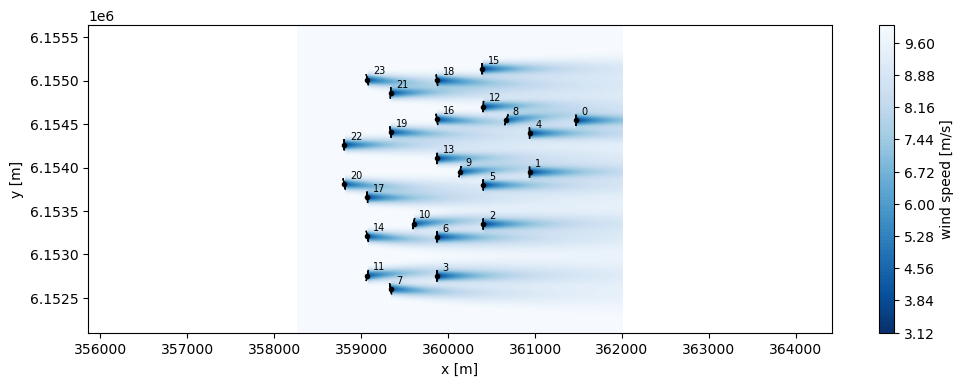

In [5]:
# Print optimized yaw angles
print("Optimized yaw angles:", state['yaw_ilk'][:, 0, 0])

# Visualize the wake map
simulationResult = wf_model(x, y, wd=wdir[0], ws=wsp[0], yaw=state['yaw_ilk'][:, 0, 0], tilt=0)
plt.figure(figsize=(12, 4))
simulationResult.flow_map().plot_wake_map()
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.show()